In [1]:
import lightkurve
import matplotlib.pyplot as plot
import numpy
import triceratops.triceratops as tr
import json

%matplotlib inline
# plot.style.use('seaborn-v0_8')
parent_folder = 'CTOI Creation'

In [2]:
data_paths = []

with open(f'{parent_folder}/queue_data_paths.txt', 'r+') as file:
    data_paths.extend([file_name.strip() for file_name in file.readlines()])
    file.seek(0)

data_paths

[]

In [3]:
data_path = data_paths[0]
data_path

IndexError: list index out of range

In [ ]:
with open(data_path, 'r') as file:
    data = json.load(file)

data

In [4]:
data = {
    'id_num': 62740096,
    'triceratops': {
        'period': 1.7530712,
        'transit_duration': 1.019,
        'transit_time': 3261.3584465143936,
        'transit_depth': 0.014919827439878075
    }
}

In [5]:
star_id = data['id_num']
star_id

62740096

In [6]:
triceratops = data['triceratops']
triceratops

{'period': 1.7530712,
 'transit_duration': 1.019,
 'transit_time': 3261.3584465143936,
 'transit_depth': 0.014919827439878075}

In [7]:
search_result = lightkurve.search_lightcurve(f'TIC {star_id}', mission = 'TESS')[:20]
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 72,2023,SPOC,120,62740096,0.0
1,TESS Sector 72,2023,TESS-SPOC,200,62740096,0.0
2,TESS Sector 44,2021,QLP,600,62740096,0.0
3,TESS Sector 45,2021,QLP,600,62740096,0.0
4,TESS Sector 46,2021,QLP,600,62740096,0.0
5,TESS Sector 72,2023,QLP,200,62740096,0.0


In [9]:
lc = search_result[1].download_all().stitch()
lc

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
3260.1884465143935,———,———,2.3630376e-03,878138,57.63759,1219.49587,5.8825946e+02,7.9233403e+00,6.6684570e+03,3.4332793e+00,———,———,1000000000000,———,———,———,———,57.63759,6.4430074e-03,1219.49587,6.2425919e-03,1.8392989e-02,1.3036759e-02
3260.1907615267583,———,———,2.3632362e-03,878139,57.64605,1219.49316,5.8161713e+02,7.9592385e+00,6.7371553e+03,3.4512966e+00,———,———,1000000000000,———,———,———,———,57.64605,6.5713124e-03,1219.49316,6.3420809e-03,1.6993487e-02,9.7099142e-03
3260.193076538889,———,———,2.3634345e-03,878140,57.63813,1219.49577,5.8694470e+02,7.9960260e+00,6.8034604e+03,3.4664543e+00,———,———,1000000000000,———,———,———,———,57.63813,6.5182736e-03,1219.49577,6.3134795e-03,9.8431027e-03,9.9621061e-03
3260.1953915512536,———,———,2.3636331e-03,878141,57.63737,1219.50331,5.8373651e+02,8.0278215e+00,6.8656470e+03,3.4811170e+00,———,———,1000000000000,———,———,———,———,57.63737,6.5782894e-03,1219.50331,6.3730581e-03,1.9037420e-02,1.3064932e-02
3260.1977065636183,———,———,2.3638317e-03,878142,57.62928,1219.50343,5.7753442e+02,8.0674543e+00,6.9443843e+03,3.5019407e+00,———,———,1000000000000,———,———,———,———,57.62928,6.6576316e-03,1219.50343,6.4722099e-03,5.1060128e-03,1.6460584e-02
3260.2000215759817,———,———,2.3640303e-03,878143,57.65126,1219.50086,5.8361652e+02,8.1034679e+00,7.0144238e+03,3.5167725e+00,———,———,1000000000000,———,———,———,———,57.65126,6.6844705e-03,1219.50086,6.4334744e-03,1.5971482e-02,1.3836090e-02
3260.2023365885793,———,———,2.3642292e-03,878144,57.66275,1219.50093,5.6645087e+02,8.1389961e+00,7.0894829e+03,3.5354114e+00,———,———,1000000000000,———,———,———,———,57.66275,6.9566169e-03,1219.50093,6.6564949e-03,2.0570224e-02,4.2903572e-03
3260.204651600944,———,———,2.3644278e-03,878145,57.63291,1219.49830,5.9175269e+02,8.1828279e+00,7.1555918e+03,3.5520730e+00,———,———,1000000000000,———,———,———,———,57.63291,6.6008931e-03,1219.49830,6.4069312e-03,1.1666263e-02,1.6384855e-02


In [10]:
period = triceratops['period']
duration = triceratops['transit_duration'] / 24
transit_time = triceratops['transit_time']
depth = triceratops['transit_depth']
sectors = [72]
exptime = 600 / 86400

In [ ]:
# import pandas

# url = 'https://stev.oapd.inaf.it/tmp/output603559110852.dat'

# data = pandas.read_csv('trilegal.tbl', delim_whitespace = True, comment = '#')
# data

In [ ]:
# data.to_csv('trilegal.csv')

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

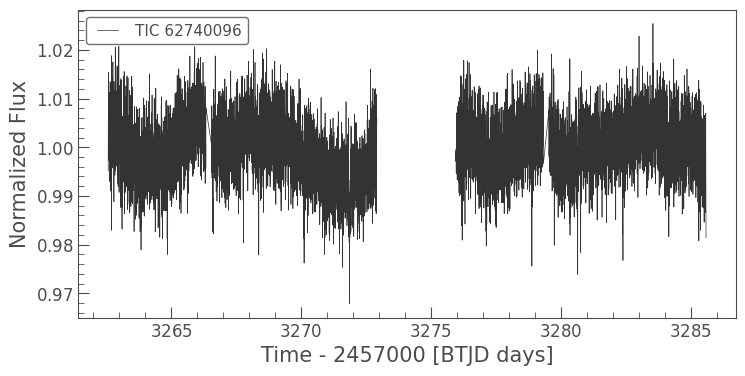

In [11]:
lc.plot()

In [ ]:
# depth += -0.005 # add extra depth after seeing folded to improve value

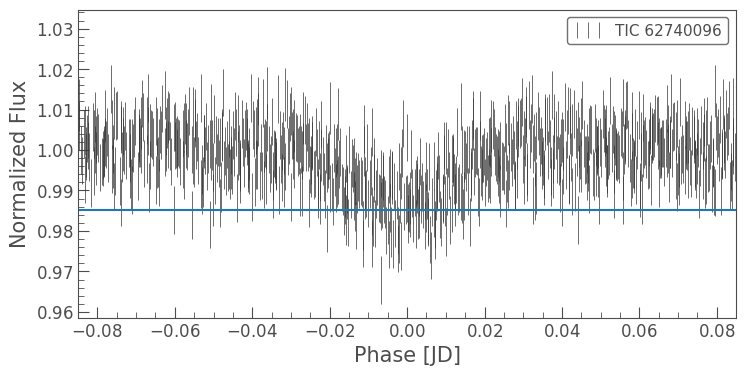

In [12]:
lc = lc.normalize()
flc = lc.fold(period = period, epoch_time = transit_time)
flc.errorbar()
plot.hlines([1 - depth], flc.time.min().value, flc.time.max().value)
plot.xlim(-duration * 2, duration * 2)
plot.show()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

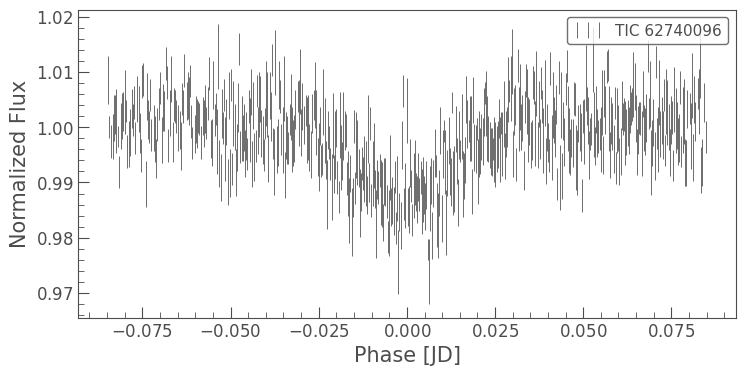

In [25]:
mask = numpy.abs(flc.time) < duration * 2
mflc = flc[mask]
blc = mflc.bin(time_bin_size = (2 * duration * 2) / 512)
blc.errorbar()

In [16]:
target = tr.target(ID = star_id, search_radius = 5, sectors = numpy.array(sectors), trilegal_fname = '')

Getting TessCut for sector 72


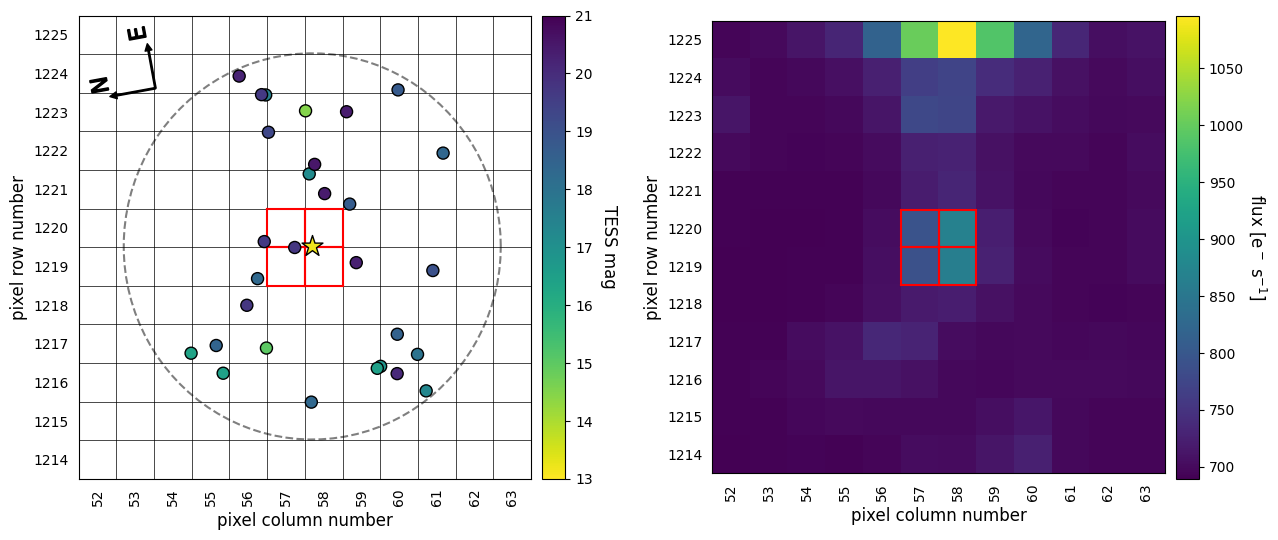

In [17]:
aps = target.get_spoc_apertures()
target.plot_field(sector = sectors[0], ap_pixels = aps[0] if aps != [] else None, ap_color = 'red')

In [18]:
target.stars

,ID,Tmag,Jmag,Hmag,Kmag,ra,dec,mass,rad,Teff,plx,sep (arcsec),PA (E of N)
0,62740096,13.1890,12.539,12.182,12.088,116.003457,20.208879,1.000000,0.892240,5625.08,1.920360,0.000,0.000
1,740184095,19.7311,NaN,NaN,NaN,116.003808,20.211582,NaN,NaN,NaN,0.067504,9.800,6.953
2,740184094,20.2908,NaN,NaN,NaN,115.999593,20.202601,NaN,NaN,NaN,2.369150,26.101,210.010
3,740184102,19.6697,NaN,NaN,NaN,116.005639,20.216073,NaN,NaN,NaN,-0.466382,26.924,15.891
4,740184096,20.4295,NaN,NaN,NaN,116.011402,20.205546,NaN,NaN,NaN,NaN,29.399,114.086
5,62740101,18.6920,17.014,16.311,16.150,116.009009,20.202012,NaN,NaN,3880.00,0.805695,31.032,142.815
6,62740091,18.3020,16.577,16.063,15.789,116.000006,20.218103,NaN,NaN,NaN,NaN,35.192,340.655
7,62740097,17.1596,15.980,15.277,15.127,116.014965,20.207360,0.480681,0.482681,3823.00,1.330550,39.260,98.006
8,740184098,20.5091,NaN,NaN,NaN,116.016302,20.206275,NaN,NaN,NaN,NaN,44.397,102.189
9,740184101,19.7441,NaN,NaN,NaN,115.996128,20.220464,NaN,NaN,NaN,0.304390,48.500,329.303


In [19]:
target.calc_depths(tdepth = depth, all_ap_pixels = aps)

In [20]:
target.stars[target.stars.tdepth > 0]

,ID,Tmag,Jmag,Hmag,Kmag,ra,dec,mass,rad,Teff,plx,sep (arcsec),PA (E of N),fluxratio,tdepth
0,62740096,13.189,12.539,12.182,12.088,116.003457,20.208879,1.0,0.89224,5625.08,1.92036,0.0,0.0,0.984472,0.015155


In [26]:
target.calc_probs(
    time = blc.time.value,                               # binned time data
    flux_0 = blc.flux.value,                             # binned flux data
    flux_err_0 = numpy.mean(blc.flux_err.value),            # standard deviation of (out-of-transit) flux data
    P_orb = period,                              # best-fit orbital period of planet candidate
    contrast_curve_file = None,        # contrast curve file to use (str)
    filt = 'TESS',                                # number of instances to simulate for each scenario (int, usually fine to leave alone)
    parallel = True,                               # whether or not to use parallel processing (bool)
    drop_scenario = ['DTP', 'DEB', 'DEBx2P', 'BTP', 'BEB', 'BEBx2P', 'NTP', 'NEB', 'NEB2xP'],                            # scenarios to ignore (e.g., "EB")
    verbose = 1,                                   # whether or not to print updates (0 or 1)
    flatpriors = False,                            # whether or not to assume flat planet priors (bool)
    exptime = exptime,                             # exposure time of TESS data (float, in days)
    molusc_file = None
)

Calculating TP scenario probabilitiey for 62740096.
Calculating EB and EBx2P scenario probabilities for 62740096.
Calculating PTP scenario probability for 62740096.
Calculating PEB and PEBx2P scenario probabilities for 62740096.
Calculating STP scenario probability for 62740096.
Calculating SEB and SEBx2P scenario probabilities for 62740096.


In [22]:
target.probs

,ID,scenario,M_s,R_s,P_orb,inc,b,ecc,w,R_p,M_EB,R_EB,prob
0,62740096,TP,1.000000,0.892240,1.753071,81.408757,0.675610,0.340520,88.582990,12.058830,0.000000,0.000000,0.605155
1,62740096,EB,1.000000,0.892240,1.753071,81.507152,0.824752,0.227233,98.153655,0.000000,0.163854,0.195838,0.060597
2,62740096,EBx2P,1.000000,0.892240,3.506142,80.066637,1.756827,0.293667,51.186009,0.000000,0.991780,0.892240,0.122855
3,62740096,PTP,1.000000,0.892240,1.753071,81.470288,0.683426,0.329421,97.325724,14.456957,0.000000,0.000000,0.064621
4,62740096,PEB,1.000000,0.892240,1.753071,75.012022,1.773236,0.239804,45.285992,0.000000,0.914450,0.892240,0.071955
5,62740096,PEBx2P,1.000000,0.892240,3.506142,80.622947,1.946462,0.195535,30.043953,0.000000,0.966426,0.892240,0.016828
6,62740096,STP,0.832579,0.859046,1.753071,78.934431,0.767612,0.437355,54.235588,19.453140,0.000000,0.000000,0.004740
7,62740096,SEB,0.860673,0.889240,1.753071,74.281751,1.623595,0.310456,44.552983,0.000000,0.757026,0.786858,0.043440
8,62740096,SEBx2P,0.695678,0.726170,3.506142,79.410425,1.786558,0.442541,31.754387,0.000000,0.688247,0.718069,0.009809
9,62740096,DTP,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [23]:
print('FPP = ', target.FPP) # eb on this star, etc.
print('NFPP = ', target.NFPP) # nearby contamination

FPP =  0.3302243690247696
NFPP =  0.0


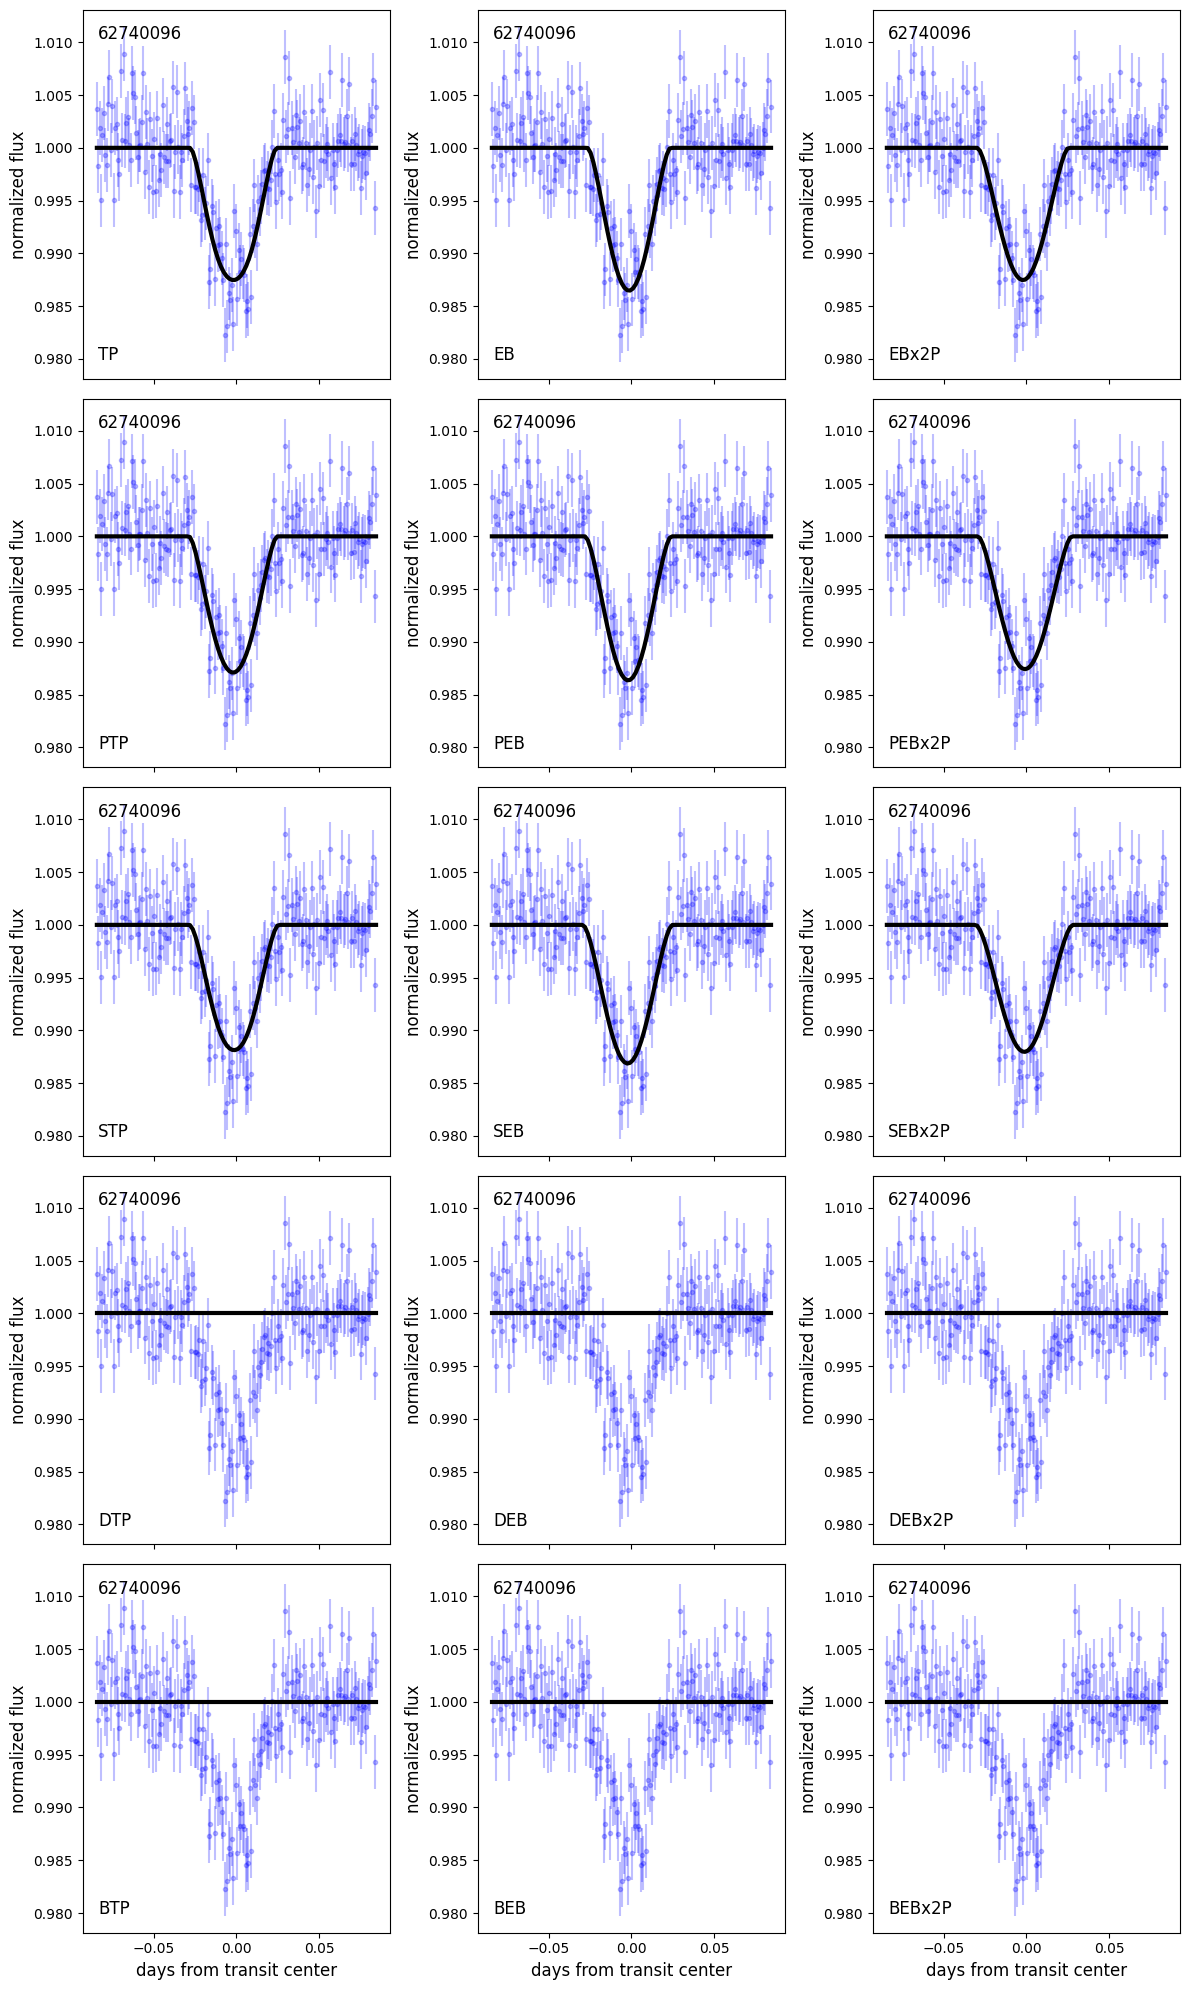

In [24]:
target.plot_fits(
    time = blc.time.value,                               # binned time data
    flux_0 = blc.flux.value,                             # binned flux data
    flux_err_0 = numpy.mean(blc.flux_err.value)
)